# Minor Project 1: Sales Performance Analysis System

## Problem Statement

Organizations collect daily sales data but often lack a clear understanding of overall performance, trends, and category-wise contributions.

This project analyzes structured sales data to extract meaningful insights using Python, Pandas, Matplotlib, and Seaborn.

## Importing Required Libraries


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Loading The Dataset

In [38]:
df = pd.read_excel("product_sales_dataset_final.csv.xlsx")
df.head()

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


## Data Inspection

In [39]:
df.shape

(10000, 14)

In [40]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'City', 'State', 'Region',
       'Country', 'Category', 'Sub_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Revenue', 'Profit'],
      dtype='object')

In [41]:
df.dtypes

,0
Order_ID,int64
Order_Date,datetime64[ns]
Customer_Name,object
City,object
State,object
Region,object
Country,object
Category,object
Sub_Category,object
Product_Name,object


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       10000 non-null  int64         
 1   Order_Date     10000 non-null  datetime64[ns]
 2   Customer_Name  10000 non-null  object        
 3   City           10000 non-null  object        
 4   State          10000 non-null  object        
 5   Region         10000 non-null  object        
 6   Country        10000 non-null  object        
 7   Category       10000 non-null  object        
 8   Sub_Category   10000 non-null  object        
 9   Product_Name   10000 non-null  object        
 10  Quantity       10000 non-null  int64         
 11  Unit_Price     10000 non-null  float64       
 12  Revenue        10000 non-null  float64       
 13  Profit         10000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(8)
memory usage: 1.1

In [43]:
df.describe()

,Order_ID,Order_Date,Quantity,Unit_Price,Revenue,Profit
count,10000.00000,10000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2024-02-14 23:28:19.199999744,1.849600,385.353689,715.869528,157.122257
min,1.00000,2023-01-01 00:00:00,1.000000,19.730000,20.300000,4.360000
25%,2500.75000,2023-09-19 00:00:00,1.000000,164.827500,230.222500,59.320000
50%,5000.50000,2024-01-10 00:00:00,1.000000,308.140000,473.755000,110.405000
75%,7500.25000,2024-09-12 00:00:00,2.000000,566.147500,890.640000,203.160000
max,10000.00000,2024-12-31 00:00:00,8.000000,1372.890000,7110.960000,1760.890000
std,2886.89568,NaN,1.088714,277.509694,738.705012,150.634933


## Checking and Handling Missing Values

In [44]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
City,0
State,0
Region,0
Country,0
Category,0
Sub_Category,0
Product_Name,0


## Exploratory Data Analysis (EDA)

In [45]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 7158695.279999999


In [46]:
avg_revenue = df['Revenue'].mean()
print("Average Revenue per Order:", avg_revenue)

Average Revenue per Order: 715.869528


In [47]:
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 1571222.5700000003


In [48]:
avg_profit = df['Profit'].mean()
print("Average Profit:", avg_profit)

Average Profit: 157.12225700000002


In [49]:
total_quantity = df['Quantity'].sum()
total_quantity

np.int64(18496)

### Category-wise Analysis

In [50]:
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
category_revenue

,Revenue
Category,
Electronics,2923782.77
Home & Furniture,2385671.95
Clothing & Apparel,1350706.07
Accessories,498534.49


In [51]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit

,Profit
Category,
Home & Furniture,555217.19
Clothing & Apparel,438677.23
Electronics,407690.04
Accessories,169638.11


### Sub-Category

In [52]:
subcat_revenue = df.groupby('Sub_Category')['Revenue'].sum().sort_values(ascending=False)
subcat_revenue

,Revenue
Sub_Category,
Laptops,673591.90
Bedding,621672.91
Smartphones,551637.26
Kitchenware,469075.59
Wearables,462542.88
Furniture,448421.09
Home Decor,447718.78
Tablets,414762.27
Home Appliances,414744.08


### Region

In [53]:
region_revenue = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
region_revenue

,Revenue
Region,
East,2340783.22
Centre,1766154.12
West,1751011.36
South,1300746.58


### Top 10 Products by Revenue

In [54]:
top_products = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

,Revenue
Product_Name,
Instant Pot,476407.43
MacBook Air,441150.74
Tempur-Pedic Mattress,421425.57
Apple Watch,317984.98
Apple iPhone 14,307399.56
iPad Pro,283543.91
KitchenAid Mixer,265519.37
Storage Rack,238509.55
Throw Pillows,201808.71


## Visualization

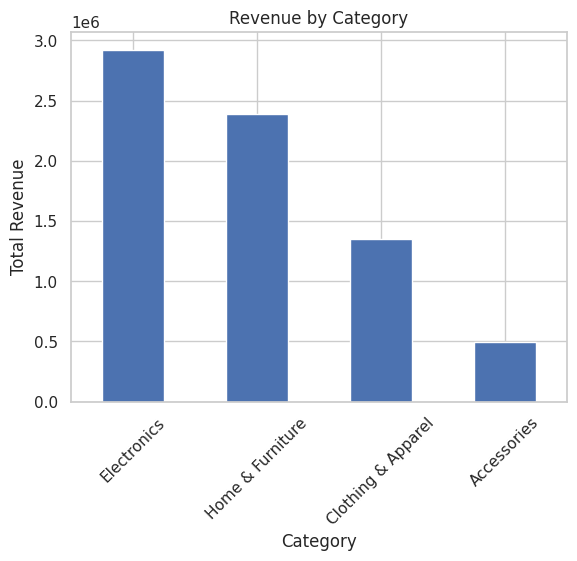

In [55]:
plt.figure()
category_revenue.plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

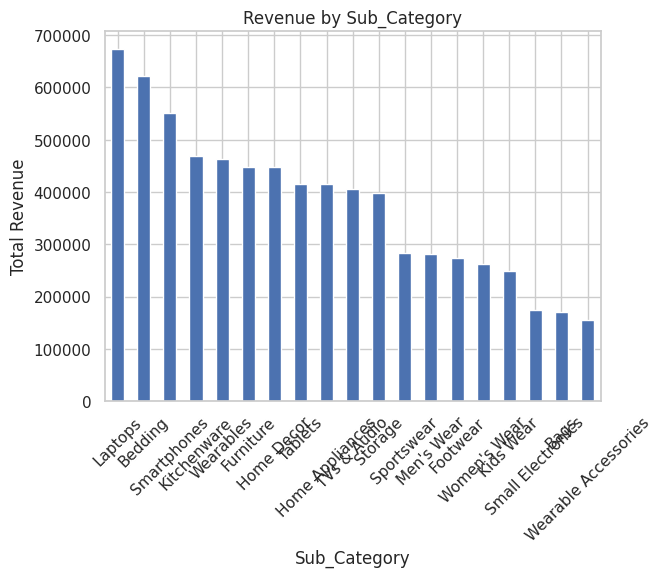

In [56]:
plt.figure()
subcat_revenue.plot(kind='bar')
plt.title("Revenue by Sub_Category")
plt.xlabel("Sub_Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

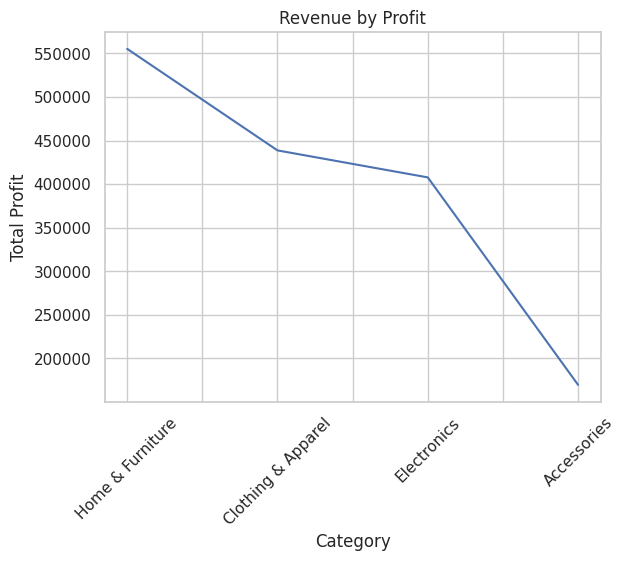

In [57]:
plt.figure()
category_profit.plot(kind='line')
plt.title("Revenue by Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

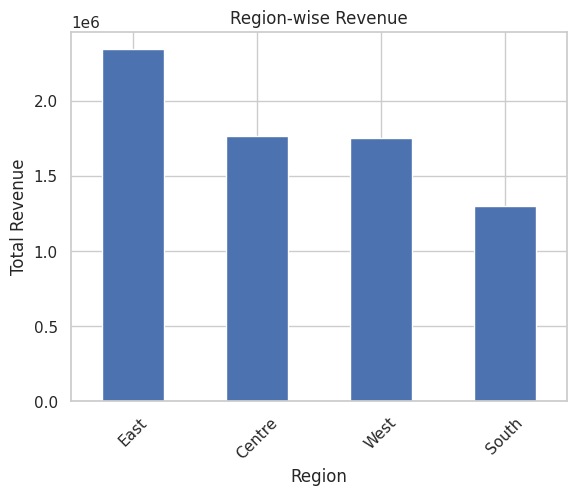

In [58]:
plt.figure()
region_revenue.plot(kind='bar')
plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

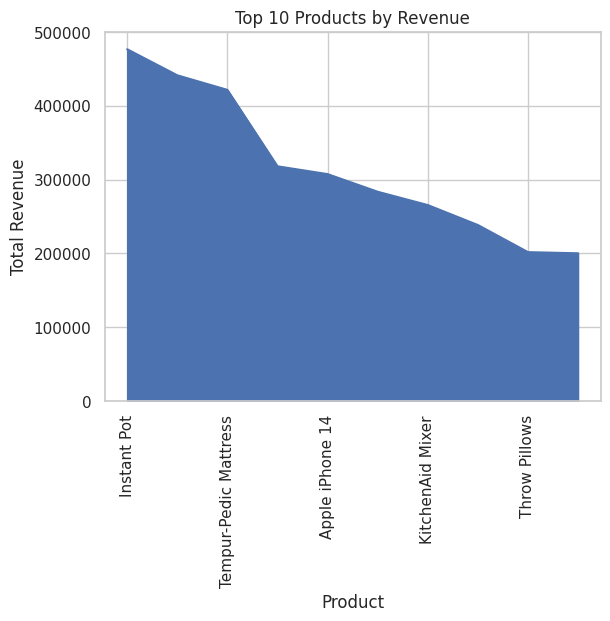

In [59]:
plt.figure()
top_products.plot(kind='area')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=90)
plt.show()

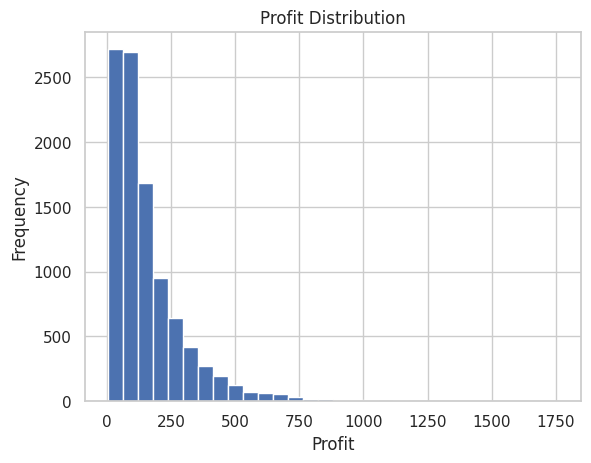

In [60]:
plt.figure()
plt.hist(df['Profit'], bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

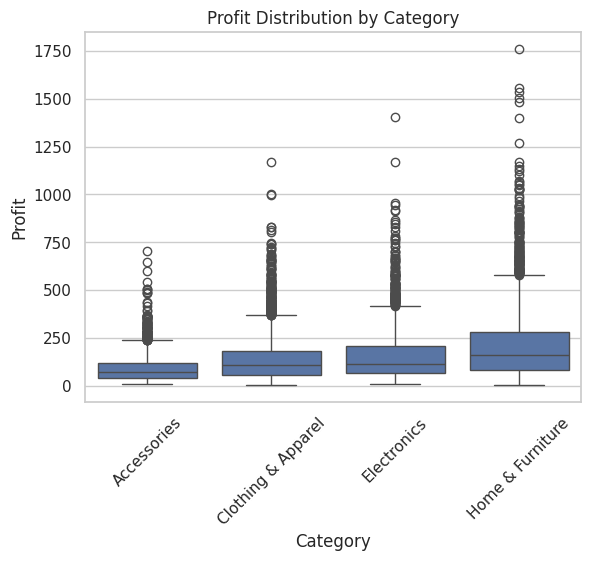

In [61]:
plt.figure()
sns.boxplot(x='Category', y='Profit', data=df)
plt.title("Profit Distribution by Category")
plt.xticks(rotation=45)
plt.show()

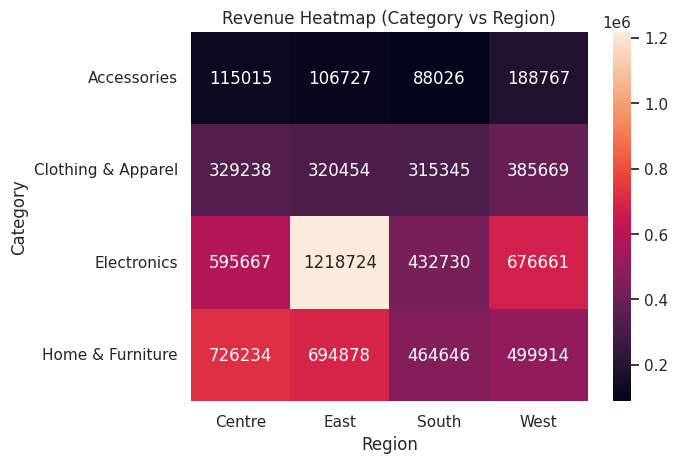

In [62]:
pivot_table = df.pivot_table(values='Revenue', index='Category', columns='Region', aggfunc='sum')

plt.figure()
sns.heatmap(pivot_table, annot=True, fmt=".0f")
plt.title("Revenue Heatmap (Category vs Region)")
plt.show()

## Summarizing Key Findings

1. Overall Revenue Performance

-> Electronics is the highest revenue-generating category (~2.9 million).

-> Home & Furniture is the second highest contributor (~2.4 million).

-> Clothing & Apparel generates moderate revenue.

-> Accessories contribute the least revenue (~0.5 million).

** Electronics dominates overall sales performance.

2. Profitability Analysis

-> Home & Furniture shows the highest median profit per order.

-> Electronics also provides strong and consistent profit margins.

-> Clothing & Apparel generates moderate profits.

-> Accessories has the lowest median profit per transaction.

** Although Electronics generates the highest revenue, Home & Furniture offers higher per-order profitability.

3. Profit Variability

-> Home & Furniture has high variability in profits (large spread in boxplot).

-> Electronics shows moderate variability.

-> Accessories profits are more consistent but lower.

-> All categories show presence of high-profit outliers, indicating occasional large-value transactions.

4. Business Insights

-> High-value transactions are concentrated in Home & Furniture and Electronics.

-> Accessories may require pricing or marketing improvements to increase profitability.

-> Revenue and profit patterns suggest focusing strategic investments on Electronics and Home & Furniture categories.